In [2]:
import pandas as pd
from great_tables import GT
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
from scipy.stats import chi2_contingency
import matplotlib.dates as mdates
from src.fonction_analyse import compter_par_mois, evolution_mensuelle, nb_accidents_par, tab_cont_grav, bar_chart

%run main.ipynb

# df_caract_recoder
# df_lieux_recoder
# df_vehicule_recoder
# df_usager_recoder
# df_final

KeyboardInterrupt: 

KeyboardInterrupt: 

In [348]:
import importlib
import src.fonction_analyse

importlib.reload(src.fonction_analyse)

<module 'src.fonction_analyse' from '/home/onyxia/work/Projet_pythonDS/src/fonction_analyse.py'>

In [21]:
ordre_colonnes = [
    "Indemne", 
    "Blessé léger", 
    "Blessé hospitalisé", 
    "Tué"
]

In [57]:
df_final

,Num_Acc,jour,mois,an,hrmn,lum,dep,agg,int,atm,...,catu,grav,sexe,trajet,secu1,age,date,jour_semaine,hr,heure_cat
0,202400000001,25,mars,2024,07:40,Crépuscule ou aube,70,Hors agglomération,Hors intersection,Brouillard - fumée,...,Conducteur,3,Homme,Domicile - École,Ceinture,23,2024-03-25,Lundi,07,Matin
1,202400000001,25,mars,2024,07:40,Crépuscule ou aube,70,Hors agglomération,Hors intersection,Brouillard - fumée,...,Conducteur,1,Homme,Utilisation professionnelle,Ceinture,29,2024-03-25,Lundi,07,Matin
2,202400000002,20,mars,2024,15:05,Plein jour,21,En agglomération,Intersection en T,Temps éblouissant,...,Piéton,3,Femme,Promenade - loisirs,Aucun équipement,99,2024-03-20,Mercredi,15,Après-midi
3,202400000002,20,mars,2024,15:05,Plein jour,21,En agglomération,Intersection en T,Temps éblouissant,...,Conducteur,1,Homme,Utilisation professionnelle,Ceinture,39,2024-03-20,Mercredi,15,Après-midi
4,202400000003,22,mars,2024,19:30,Crépuscule ou aube,15,Hors agglomération,Hors intersection,Normale,...,Passager,2,Femme,Promenade - loisirs,Non déterminable,19,2024-03-22,Vendredi,19,Soir
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
377697,202200055301,1,janvier,2022,08:40,Plein jour,81,Hors agglomération,Intersection en T,Normale,...,Conducteur,1,Femme,Promenade - loisirs,Ceinture,24,2022-01-01,Samedi,08,Matin
377698,202200055301,1,janvier,2022,08:40,Plein jour,81,Hors agglomération,Intersection en T,Normale,...,Passager,3,Femme,Promenade - loisirs,Ceinture,22,2022-01-01,Samedi,08,Matin
377699,202200055301,1,janvier,2022,08:40,Plein jour,81,Hors agglomération,Intersection en T,Normale,...,Conducteur,2,Femme,Promenade - loisirs,Ceinture,73,2022-01-01,Samedi,08,Matin
377700,202200055302,1,mars,2022,16:55,Plein jour,41,En agglomération,Hors intersection,Normale,...,Conducteur,3,Homme,Domicile - Travail,Casque,34,2022-03-01,Mardi,16,Après-midi


In [61]:
df_final["grav"]

0         3
1         1
2         3
3         1
4         2
         ..
377697    1
377698    3
377699    2
377700    3
377701    1
Name: grav, Length: 367669, dtype: int64

ValueError: List of boxplot statistics and `positions` values must have same the length

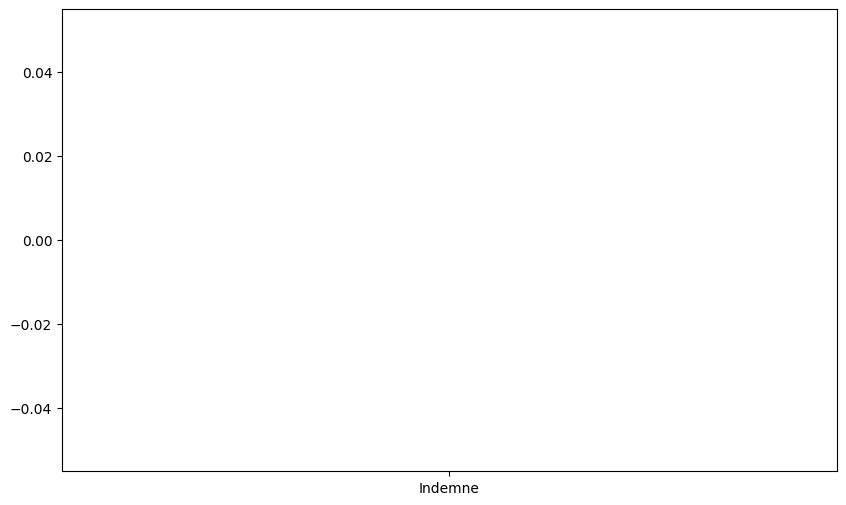

In [60]:
import seaborn as sns
import matplotlib.pyplot as plt

ordre_grav = ["Indemne", "Blessé léger", "Blessé hospitalisé", "Tué"]

fig, ax = plt.subplots(figsize=(10, 6))

sns.boxplot(
    data=df_final,
    x="grav",
    y="age",
    order=ordre_grav,  # ← impose l'ordre des modalités
    ax=ax
)

ax.set_title("Distribution de l'âge selon la gravité des blessures")
ax.set_xlabel("Gravité")
ax.set_ylabel("Âge")

plt.tight_layout()
plt.show()

In [44]:

def chi2_cramer(df: pd.DataFrame, cible: str) -> pd.DataFrame:
    """
    Calcule le chi2 et le V de Cramér entre la variable cible et une liste de variables qualitatives.

    Parameters
    ----------
    df : pd.DataFrame
    cible : str
        La variable à expliquer (ici "grav").
    variables : list[str]
        Liste variables explicatives qualitatives à tester.

    Returns
    -------
    pd.DataFrame
        Tableau récapitulatif trié par V de Cramér décroissant.
    """
    resultats = []
    variables = [
        "mois",
        "lum",
        "dep",
        "agg",
        "int",
        "atm",
        "col",
        "catr",
        "circ",
        "vosp",
        "prof",
        "plan",
        "surf",
        "infra",
        "situ",
        "catv",
        "obs",
        "obsm",
        "choc",
        "manv",
        "catu",
        "sexe",
        "trajet",
        "secu1",
        "jour_semaine",
        "hr"
    ]
    labels = {
        "mois": "Mois de l'accident",
        "lum": "Luminosité et conditions d'éclairage",
        "dep": "Département de l'accident",
        "agg": "En ou hors agglomération",
        "int": "Intersection",
        "atm": "Conditions atmosphériques",
        "col": "Type de collision",
        "catr": "Catégorie de route",
        "circ": "Régime de circulation",
        "vosp": "Existence d'une voie réservée",
        "prof": "Déclivité de la route à l'endroit de l'accident",
        "plan": "Tracé en plan",
        "surf": "État de la surface",
        "infra": "Infrastructure ou aménagement",
        "situ": "Situation de l'accident",
        "catv": "Catégorie du véhicule",
        "obs": "Obstacle fixe heurté",
        "obsm": "Obstacle mobile heurté",
        "choc": "Point de choc initial",
        "manv": "Manoeuvre principale avant l'accident",
        "catu": "Catégorie de l'usager",
        "sexe": "Sexe de l'usager",
        "trajet": "Type de trajet",
        "secu1": "Équipement de sécurité",
        "jour_semaine": "Jour de la semaine",
        "hr": "Heure"
    }

    for var in variables:
        # Tableau de contingence
        tab = pd.crosstab(df[cible], df[var])

        # Test du chi2
        chi2, p_value, dof, _ = chi2_contingency(tab)

        # V de Cramér
        n = tab.sum().sum()
        k = min(tab.shape) - 1
        v_cramer = np.sqrt(chi2 / (n * k))

        resultats.append({
            "variable": var,
            "chi2": round(chi2, 2),
            "p_value": p_value,
            "ddl": dof,
            "v_cramer": round(v_cramer, 4)
        })

    tableau =(
        pd.DataFrame(resultats)
        .sort_values("v_cramer", ascending=False)
        .reset_index(drop=True)
    )
    
    tableau["variable"] = tableau["variable"].map(labels)

    return tableau


chi2_cramer = chi2_cramer(df_final, "grav")[["variable", "v_cramer"]]

In [46]:
def tableau_propre_cramer(df_chi2_cramer: pd.DataFrame):
    """
    Formatage en tableaux propre des dataframes récapitulatifs des V de Cramèr.

    Parameters
    ----------
    df_eff_freq : pd.DataFrame
        Le tableau à formater.

    Returns
    -------
    GT
        Le tableau mis au propre.
    """

    labels = dict(
        variable="Variable",
        # p_value="p-value du test",
        v_cramer="V de Cramèr"
    )

    table = (
        GT(df_chi2_cramer)
        # .fmt_number(columns="p_value", dec_mark=",")
        .fmt_number(columns="v_cramer", dec_mark=",")
        .tab_header(
            subtitle="""
                Résultats des V de Cramèr
                entre la gravité et différentes variables qualitatives
            """,
            title="Association entre la gravité et différentes variables"
        )
        .cols_label(**labels)
        .cols_align(align="right")
        .cols_align(align="left", columns="variable")
    )

    return table


tableau_propre_cramer(chi2_cramer)

GT(_tbl_data=                                           variable  v_cramer
0                            Équipement de sécurité    0.2671
1                             Catégorie du véhicule    0.2443
2                             Catégorie de l'usager    0.1669
3                          En ou hors agglomération    0.1662
4             Manoeuvre principale avant l'accident    0.1605
5                         Département de l'accident    0.1548
6                              Obstacle fixe heurté    0.1547
7                                 Type de collision    0.1511
8                            Obstacle mobile heurté    0.1443
9                           Situation de l'accident    0.1285
10                            Point de choc initial    0.1274
11                                   Type de trajet    0.1244
12                               Catégorie de route    0.1033
13                                 Sexe de l'usager    0.0914
14                            Régime de circulation    0.0862
15                                    Tracé en plan    0.0712
16             Luminosité et conditions d'éclairage    0.0684
17                                     Intersection    0.0564
18                                            Heure    0.0546
19  Déclivité de la route à l'endroit de l'accident    0.0416
20                    Existence d'une voie réservée    0.0394
21                        Conditions atmosphériques    0.0329
22                               Jour de la semaine    0.0315
23                    Infrastructure ou aménagement    0.0270
24                               État de la surface    0.0263
25                               Mois de l'accident    0.0218, _body=<great_tables._gt_data.Body object at 0x7f2787677480>, _boxhead=Boxhead([ColInfo(var='variable', type=<ColInfoTypeEnum.default: 1>, column_label='Variable', column_align='left', column_width=None), ColInfo(var='v_cramer', type=<ColInfoTypeEnum.default: 1>, column_label='V de Cramèr', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x7f27db176e60>, _spanners=Spanners([]), _heading=Heading(title='Association entre la gravité et différentes variables', subtitle='\n                Résultats des V de Cramèr\n                entre la gravité et différentes variables qualitatives\n            ', preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x7f27dd183410>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x7f27dd180290>, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x7f27db1773e0>, _formats=[<great_tables._gt_data.FormatInfo object at 0x7f27dd180d70>], _substitutions=[], _col_merge=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', t

In [4]:
# Y a-t-il des id_usager dupliqués ?
print(df_final['id_usager'].duplicated().sum())

# Combien de lignes perdrait-on avec le drop_duplicates ?
print(len(df_final), "→", len(df_final.drop_duplicates(subset='id_usager')))

0
367669 → 367669


In [ ]:
# def effectif_frequence(df: pd.DataFrame, variable: str):
#     """Construit un tableau qui résume les effectifs et les fréquences pour une variable.

#     Parameters
#     ----------
#     df : pd.DataFrame
#         Le DataFrame sur lequel appliquer la fonction.
#     variable : str
#         La variable du DataFrame dont on veut les effectifs et la fréquence.

#     Returns
#     -------
#     pd.DataFrame
#         Le tableau avec les effectifs et les fréquences.
#     """

#     effectif = pd.crosstab(df[variable], columns='count').reindex(columns=ordre_colonnes)
#     frequence = pd.crosstab(df[variable], columns='count', normalize=True).round(4)

#     tableau = pd.concat([effectif, frequence], axis=1)
#     tableau.columns = ["effectif", "frequence"]


#     total = pd.DataFrame(
#         {"effectif": tableau["effectif"].sum(), "frequence": tableau["frequence"].sum()},
#         index=["Total"]
#     )
#     tableau = pd.concat([tableau, total])

#     tableau = tableau.reset_index()                    # ← l'index devient une colonne
#     tableau = tableau.rename(columns={"index": variable})

#     return tableau

# effectif_frequence(df_final, "grav")



ValueError: Length mismatch: Expected axis has 5 elements, new values have 2 elements

In [49]:


def effectif_frequence(
    df: pd.DataFrame,
    variable: str
):
    """Effectue un tableau avec les effectifs et fréquences d'une variable.

    Parameters
    ----------
    df : pd.DataFrame
        Le DataFrame sur lequel appliquer la fonction.
    variable : str
        La variable du DataFrame dont on veut la répartition des modalités.

    Returns
    -------
    pd.DataFrame
        Le tableau avec les effectifs et fréquences de chaque modalité, ainsi que le total.
    """
    effectif = pd.crosstab(df[variable], columns='count')
    frequence = pd.crosstab(df[variable], columns='count', normalize=True).round(4)

    tableau = pd.concat([effectif, frequence], axis=1)
    tableau.columns = ["effectif", "frequence"]

    # Réordonne les lignes selon ordre_lignes
    tableau = tableau.reindex([1, 2, 3, 4])

    total = pd.DataFrame(
        {"effectif": tableau["effectif"].sum(), "frequence": tableau["frequence"].sum()},
        index=["Total"]
    )
    tableau = pd.concat([tableau, total])

    tableau = tableau.reset_index()
    tableau = tableau.rename(columns={"index": variable})

    # Remplace les codes par les noms complets (Total ne change pas)
    labels_modalites = {
        1: "Indemne",
        2: "Blessé léger",
        3: "Blessé hospitalisé",
        4: "Tué"
    }
    tableau[variable] = tableau[variable].map(labels_modalites).fillna("Total")

    return tableau


effectif_frequence(df_final, "grav")

,grav,effectif,frequence
0,Indemne,151600,0.4123
1,Blessé léger,148509,0.4039
2,Blessé hospitalisé,57271,0.1558
3,Tué,10289,0.0280
4,Total,367669,1.0000


In [47]:
def effectif_frequence(
    df: pd.DataFrame,
    variable: str
):
    """Effectue un tableau avec les effectifs et fréquences d'une variable.

    Parameters
    ----------
    df : pd.DataFrame
        Le DataFrame sur lequel appliquer la fonction.
    variable : str
        La variable du DataFrame dont on veut la répartition des modalités.

    Returns
    -------
    pd.DataFrame
        Le tableau avec les effectifs et fréquences de chaque modalité, ainsi que le total.
    """
    effectif = pd.crosstab(df[variable], columns='count')
    frequence = pd.crosstab(df[variable], columns='count', normalize=True).round(4)

    tableau = pd.concat([effectif, frequence], axis=1)
    tableau.columns = ["effectif", "frequence"]

    # Réordonne les lignes selon ordre_lignes
    tableau = tableau.reindex([1, 2, 3, 4])

    total = pd.DataFrame(
        {"effectif": tableau["effectif"].sum(), "frequence": tableau["frequence"].sum()},
        index=["Total"]
    )
    tableau = pd.concat([tableau, total])

    tableau = tableau.reset_index()
    tableau = tableau.rename(columns={"index": variable})

    # Remplace les codes par les noms complets, "Total" reste "Total"
    labels_modalites = {
        1: "Indemne",
        2: "Blessé léger",
        3: "Blessé hospitalisé",
        4: "Tué"
    }
    tableau[variable] = tableau[variable].map(labels_modalites).fillna("Total")

    return tableau


effectif_frequence(df_final, "grav")

,grav,effectif,frequence
0,Indemne,151600,0.4123
1,Blessé léger,148509,0.4039
2,Blessé hospitalisé,57271,0.1558
3,Tué,10289,0.0280
4,Total,367669,1.0000


In [48]:

def tableau_propre_effectif_frequence(df_eff_freq: pd.DataFrame):
    """
    Formatage en tableaux propre des dataframes des effectifs et fréquences.

    Parameters
    ----------
    df_eff_freq : pd.DataFrame
        Le tableau à formater.

    Returns
    -------
    GT
        Le tableau mis au propre.
    """

    labels = dict(
        effectif="Effectif",
        frequence="Fréquence",
        grav="Gravité"
    )

    table = (
        GT(df_eff_freq)
        .fmt_number(columns="effectif", decimals=0, sep_mark=" ")
        .fmt_percent(columns="frequence", decimals=1, dec_mark=",")
        .tab_header(
            subtitle="Répartition des effectifs et des fréquences pour la variable « gravité »",
            title="Gravité des accidents pour les usagers"
        )
        .cols_label(**labels)
        .cols_align(align="right")
        .cols_align(align="left", columns="grav")
    )

    return table

eff_freq = effectif_frequence(df_final, "grav")
tableau_propre_effectif_frequence(eff_freq)

GT(_tbl_data=                 grav  effectif  frequence
0             Indemne    151600     0.4123
1        Blessé léger    148509     0.4039
2  Blessé hospitalisé     57271     0.1558
3                 Tué     10289     0.0280
4               Total    367669     1.0000, _body=<great_tables._gt_data.Body object at 0x7f2787674230>, _boxhead=Boxhead([ColInfo(var='grav', type=<ColInfoTypeEnum.default: 1>, column_label='Gravité', column_align='left', column_width=None), ColInfo(var='effectif', type=<ColInfoTypeEnum.default: 1>, column_label='Effectif', column_align='right', column_width=None), ColInfo(var='frequence', type=<ColInfoTypeEnum.default: 1>, column_label='Fréquence', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x7f27db177280>, _spanners=Spanners([]), _heading=Heading(title='Gravité des accidents pour les usagers', subtitle='Répartition des effectifs et des fréquences pour la variable « gravité »', preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x7f27dd181550>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x7f27dd180b30>, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x7f27db1771d0>, _formats=[<great_tables._gt_data.FormatInfo object at 0x7f27dd182270>, <great_tables._gt_data.FormatInfo object at 0x7f27dd182870>], _substitutions=[], _col_merge=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_top_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_top_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_right_style=OptionsInfo(scss=True, category='table', type='value', value='none'), table_border_right_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_right_color=OptionsInfo(scss=True, category='table', type='value', value='#D3D3D3'), table_border_bottom_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_bottom_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_bottom_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_bottom_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_left_style=OptionsInfo(scss=True, category='table', type='value', value='none'), table_border_left_width=OptionsInfo(scss

In [ ]:

pd.crosstab(df_final['grav'], columns='count', normalize=False)

pd.crosstab(df_final['grav'], columns='count', normalize=True).mul(100).round(2)

## Visualisation des données

In [350]:
df_final.head(3)

,Num_Acc,jour,mois,an,hrmn,lum,dep,agg,int,atm,...,id_usager,catu,grav,sexe,trajet,secu1,age,date,jour_semaine,hr
0,202400000001,25,mars,2024,07:40,Crépuscule ou aube,70,Hors agglomération,Hors intersection,Brouillard - fumée,...,203 988 581,Conducteur,Blessé hospitalisé,Homme,Domicile - École,Ceinture,23,2024-03-25,Lundi,07
1,202400000001,25,mars,2024,07:40,Crépuscule ou aube,70,Hors agglomération,Hors intersection,Brouillard - fumée,...,203 988 582,Conducteur,Indemne,Homme,Utilisation professionnelle,Ceinture,29,2024-03-25,Lundi,07
2,202400000002,20,mars,2024,15:05,Plein jour,21,En agglomération,Intersection en T,Temps éblouissant,...,203 988 579,Piéton,Blessé hospitalisé,Femme,Promenade - loisirs,Aucun équipement,99,2024-03-20,Mercredi,15


In [351]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 367699 entries, 0 to 377701
Data columns (total 40 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   Num_Acc       367699 non-null  Int64         
 1   jour          367699 non-null  int64         
 2   mois          367699 non-null  object        
 3   an            367699 non-null  int64         
 4   hrmn          367699 non-null  object        
 5   lum           367699 non-null  object        
 6   dep           367699 non-null  object        
 7   agg           367699 non-null  object        
 8   int           367699 non-null  object        
 9   atm           367699 non-null  object        
 10  col           367699 non-null  object        
 11  lat           367699 non-null  object        
 12  long          367699 non-null  object        
 13  mois_num      367699 non-null  int64         
 14  catr          367699 non-null  object        
 15  circ          345149 n

In [ ]:
[
    "mois",
    "lum",
    "dep",
    "agg",
    "int",
    "atm",
    "col",
    "catr",
    "circ",
    "nbv",
    "vosp",
    "prof",
    "plan",
    "surf",
    "infra",
    "situ",
    "catv",
    "obs",
    "obsm",
    "choc",
    "manv",
    "catu",
    "sexe",
    "trajet",
    "secu1",
    "jour_semaine",
    "hr"
]

`describe` nous renseigne sur la distribution des variables numériques :

In [352]:
df_final.describe()

,Num_Acc,jour,an,mois_num,vma,age,date
count,367699.0,367699.000000,367699.000000,367699.000000,367699.000000,367699.0,367699
mean,202299675571.364563,15.550197,2022.996481,6.658762,58.701378,41.752953,2023-07-04 20:18:36.639425024
min,202200000001.0,1.000000,2022.000000,1.000000,-1.000000,2.0,2022-01-01 00:00:00
25%,202200041217.5,8.000000,2022.000000,4.000000,50.000000,26.0,2022-09-28 00:00:00
50%,202300027260.0,15.000000,2023.000000,7.000000,50.000000,38.0,2023-07-07 00:00:00
75%,202400013566.5,23.000000,2024.000000,10.000000,80.000000,55.0,2024-04-09 00:00:00
max,202400054402.0,31.000000,2024.000000,12.000000,900.000000,113.0,2024-12-31 00:00:00
std,81705646.139283,8.741702,0.817058,3.353165,27.757948,19.146413,NaN


## Évolution du nombre d'accidents dans le temps

### Évolution globale

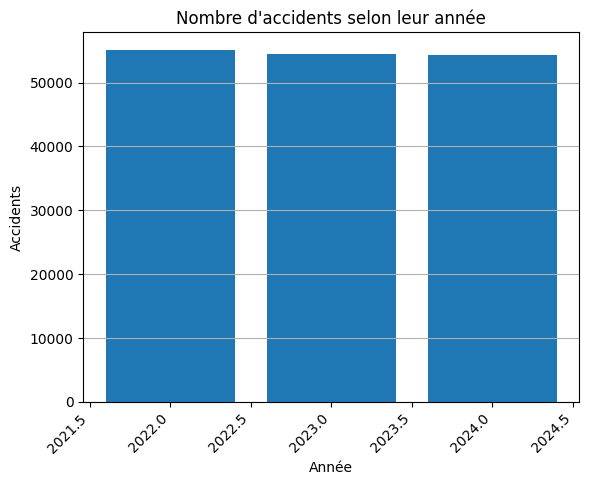

In [353]:
nb_accidents_par(df_final, "an", "Année")

Le nombre d'accidents est comparable entre les trois années.

On observe une légère tendance à la hausse, malgré des variations assez importantes selon les périodes.

In [354]:
df_final.drop_duplicates(subset="id_usager").groupby("grav").size().reset_index("Nombre")

KeyError: 'Requested level (Nombre) does not match index name (grav)'

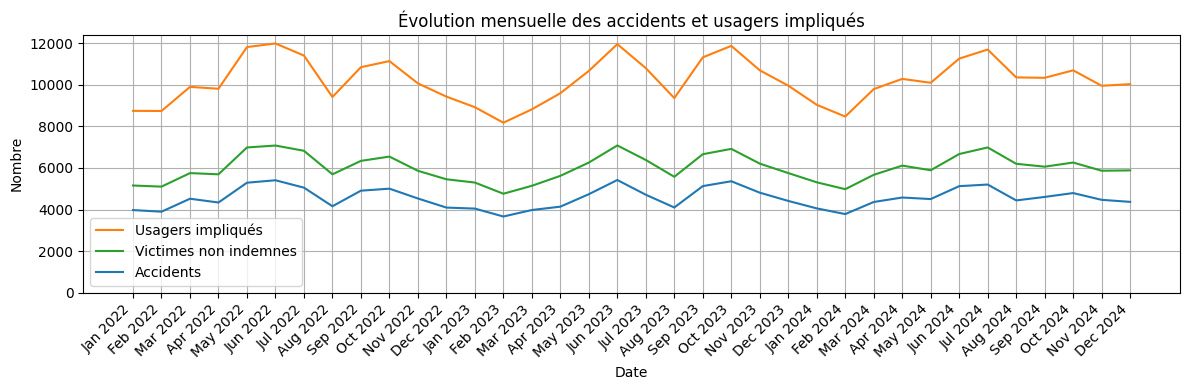

In [ ]:
evolution_mensuelle(df_final)

### Évolution horaire

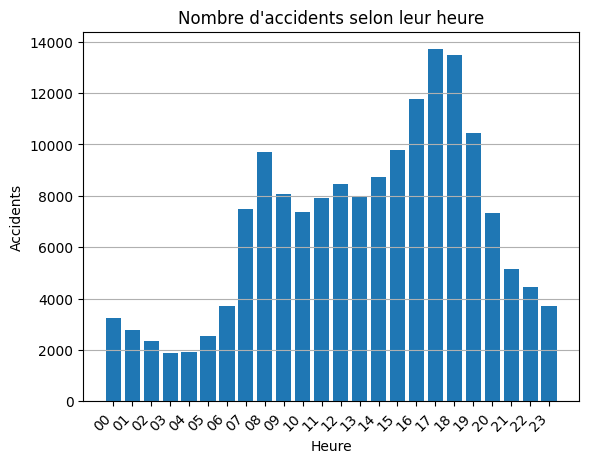

In [ ]:
nb_accidents_par(df_final, "hr", "Heure")

On observe deux modes aux heures de pointes, à 8 et 17 heures. Les accidents sont ensuite plus nombreux de jour que de nuit, et on peut supposer que leur nombre reflète globalement le trafic.

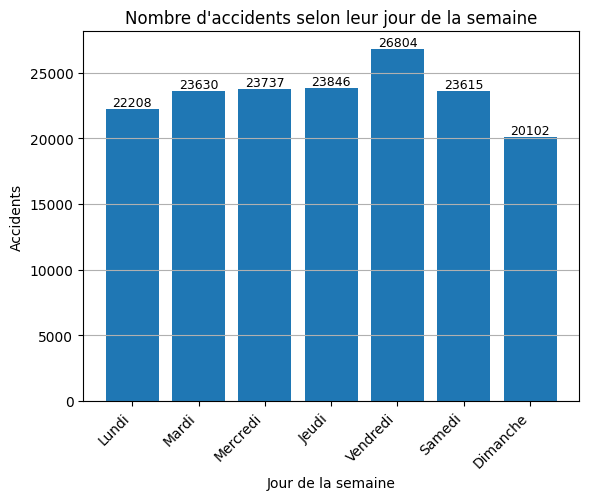

In [ ]:
ordre = ["Lundi", "Mardi", "Mercredi", "Jeudi", "Vendredi", "Samedi", "Dimanche"]
nb_accidents_par(df_final, "jour_semaine", "Jour de la semaine", ordre, True)

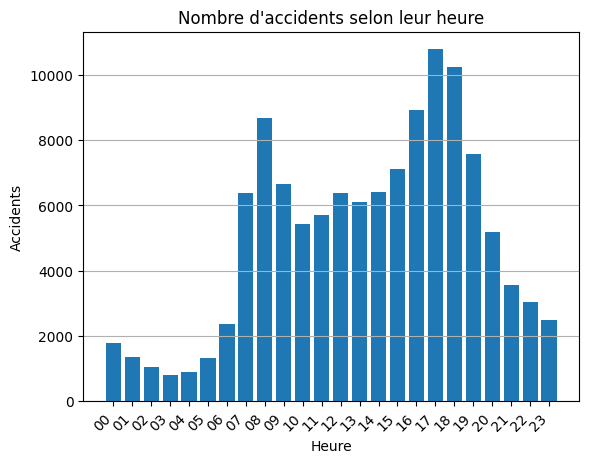

In [ ]:

nb_accidents_par(df_final[df_final["jour_semaine"].isin(["Lundi", "Mardi", "Mercredi", "Jeudi", "Vendredi"])], "hr", "Heure")

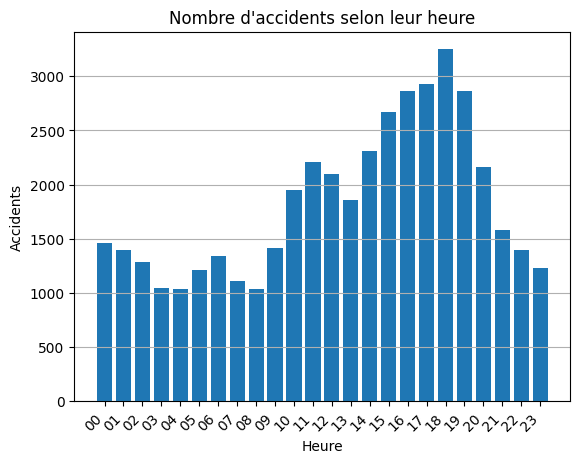

In [ ]:
nb_accidents_par(df_final[df_final["jour_semaine"].isin(["Samedi", "Dimanche"])], "hr", "Heure")

## Nombre et gravité des accidents selon les facteurs extérieurs

### Tests

In [ ]:
def test_chi2(variable1, variable2):
    tc = pd.crosstab(df_final[variable1], df_final[variable2])
    chi2, p_value, dof, expected = chi2_contingency(tc)
    print(f"Chi² = {chi2:.2f}")
    print(f"p-value = {p_value:.4f}")
    print(f"Degrés de liberté = {dof}")

In [ ]:
chi2_contingency(tc_atm_grav)

Chi2ContingencyResult(statistic=np.float64(nan), pvalue=np.float64(nan), dof=27, expected_freq=array([[nan, nan, nan, nan],
       [nan, nan, nan, nan],
       [nan, nan, nan, nan],
       [nan, nan, nan, nan],
       [nan, nan, nan, nan],
       [nan, nan, nan, nan],
       [nan, nan, nan, nan],
       [nan, nan, nan, nan],
       [nan, nan, nan, nan],
       [nan, nan, nan, nan]]))

In [ ]:
test_chi2("atm", "grav")

Chi² = 1191.94
p-value = 0.0000
Degrés de liberté = 24


### Conditions routières


#### Catégorie de route

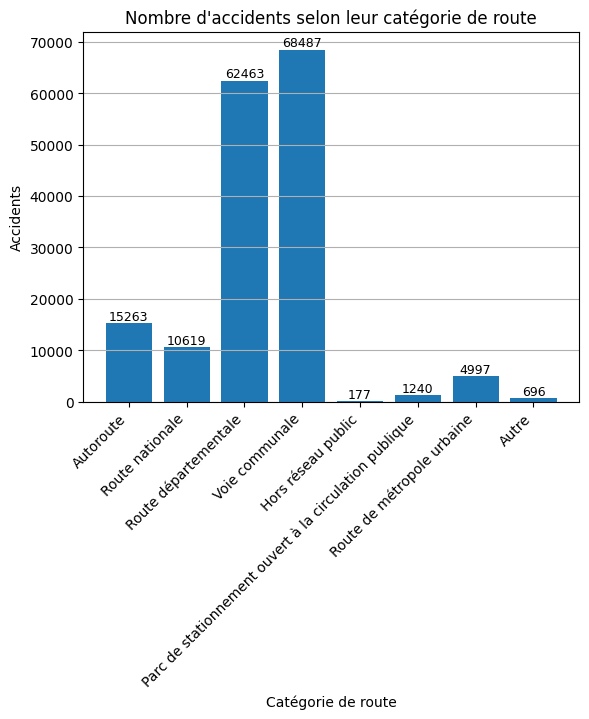

In [ ]:
ordre_lignes = [
    "Autoroute",
    "Route nationale",
    "Route départementale",
    "Voie communale",
    "Hors réseau public",
    "Parc de stationnement ouvert à la circulation publique",
    "Route de métropole urbaine",
    "Autre"
]
nb_accidents_par(df_final, "catr", "Catégorie de route", ordre_lignes, True)

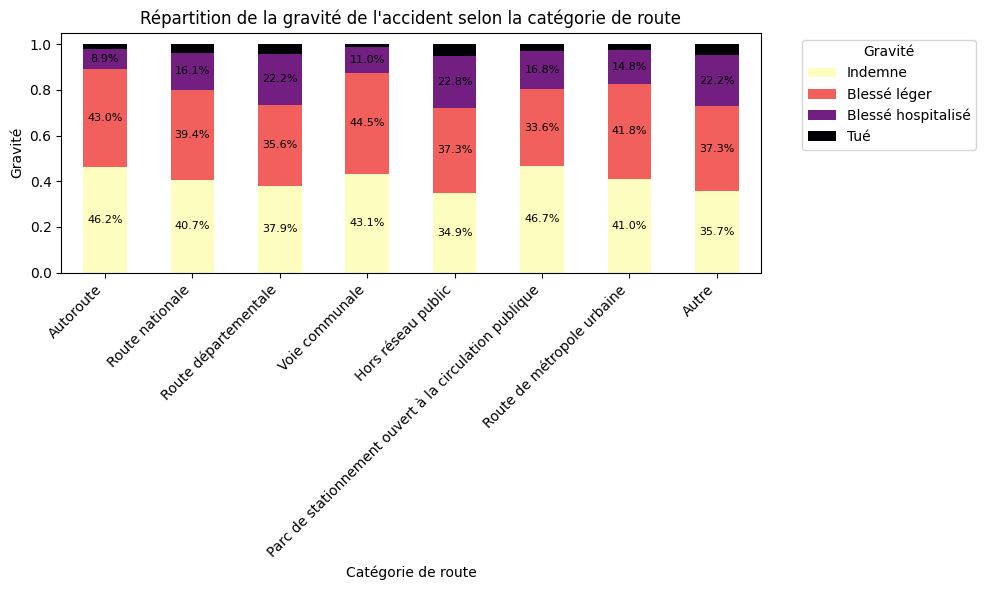

#### Agglomération

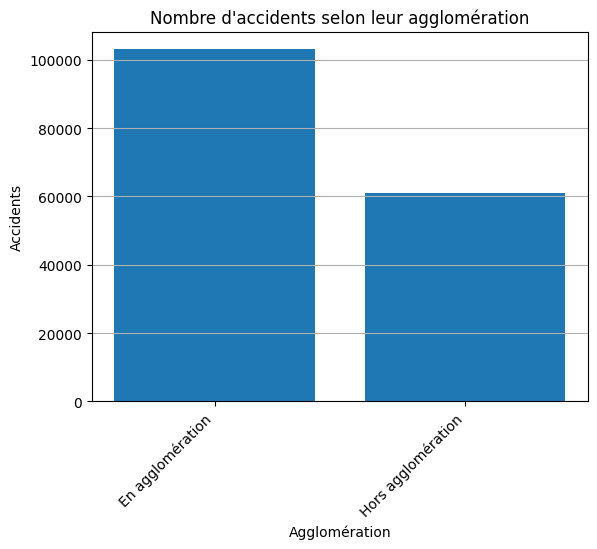

In [ ]:
nb_accidents_par(df_final, "agg", "Agglomération")

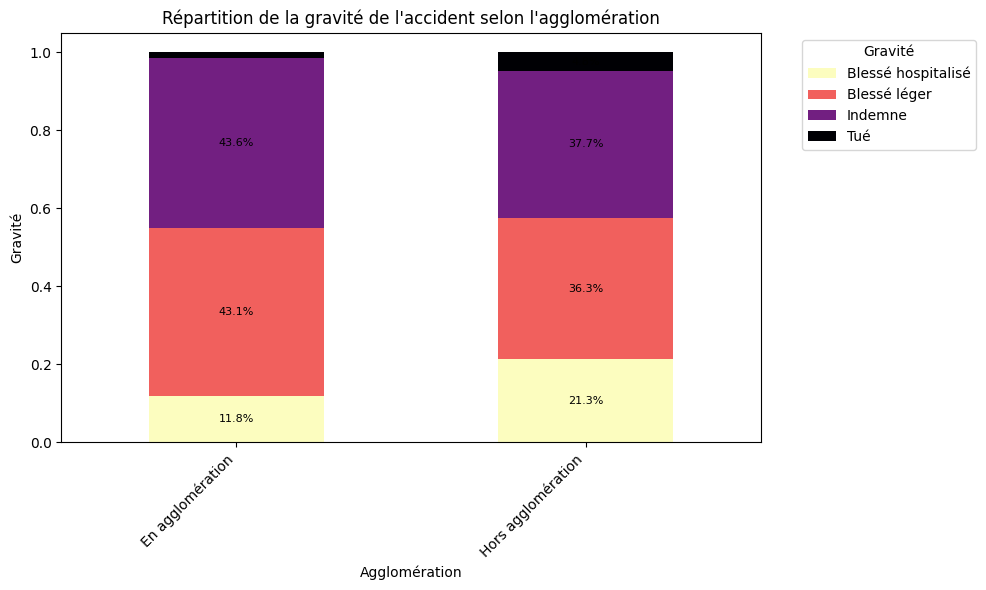

In [ ]:

tc_agg_grav = pd.crosstab(df_final["agg"], df_final["grav"], normalize='index')
bar_chart(tc_agg_grav, "Agglomération", "Répartition de la gravité de l'accident selon l'agglomération")

### Conditions atmosphériques et météorologiques

#### Conditions d'éclairage

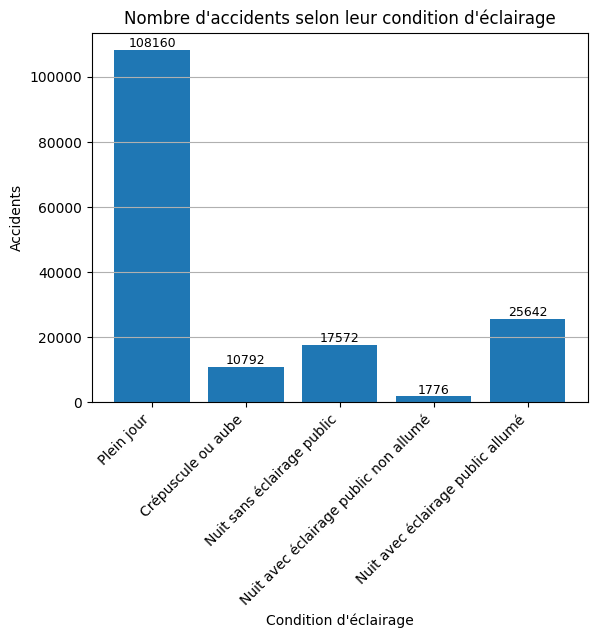

In [ ]:
ordre_lignes_lum  = [
    "Plein jour",
    "Crépuscule ou aube",
    "Nuit sans éclairage public",
    "Nuit avec éclairage public non allumé",
    "Nuit avec éclairage public allumé"
]

nb_accidents_par(df_final, "lum", "Condition d'éclairage", ordre_lignes_lum, True)

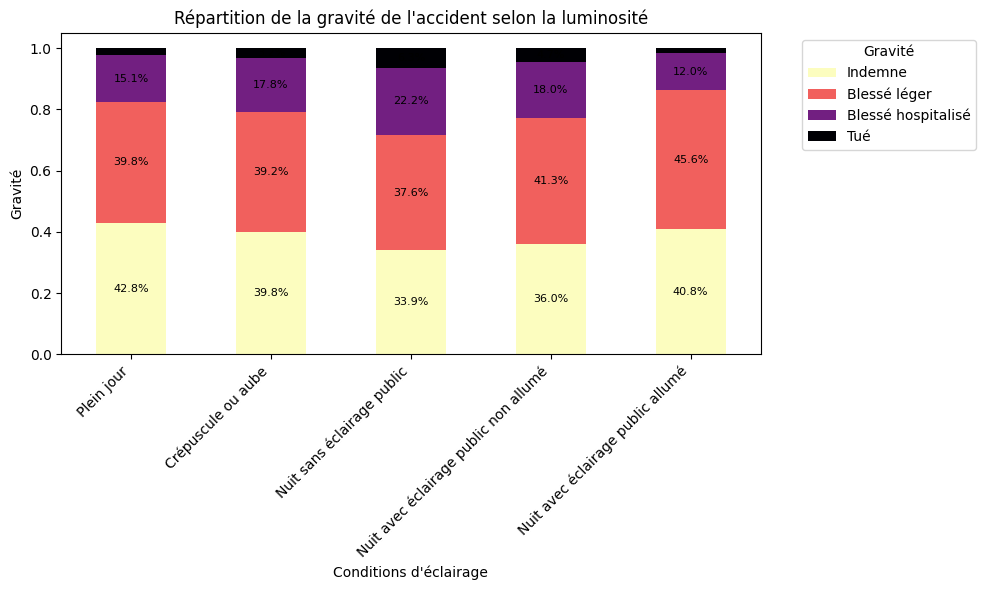

In [ ]:


tc_lum_grav = tab_cont_grav(df_final, "lum", ordre_lignes, ordre_colonnes)
bar_chart(tc_lum_grav, "Conditions d'éclairage", "Répartition de la gravité de l'accident selon la luminosité")

#### Conditions atmosphériques

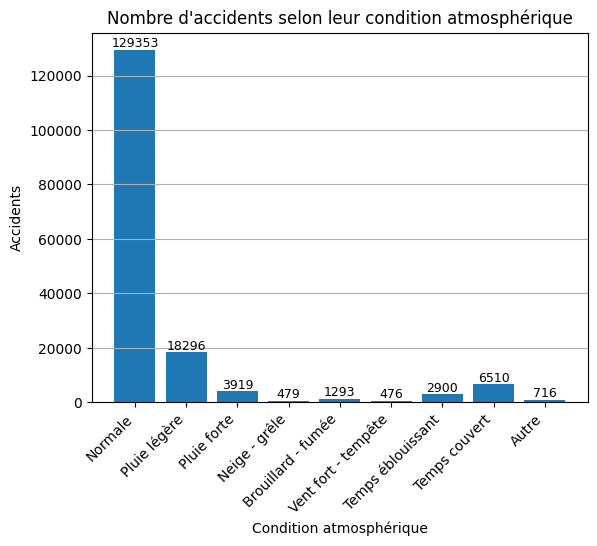

In [ ]:
ordre_lignes_atm = [
    "Normale", 
    "Pluie légère", 
    "Pluie forte", 
    "Neige - grêle", 
    "Brouillard - fumée", 
    "Vent fort - tempête", 
    "Temps éblouissant", 
    "Temps couvert", 
    "Autre"
]
nb_accidents_par(df_final, "atm", "Condition atmosphérique", ordre_lignes_atm, True)

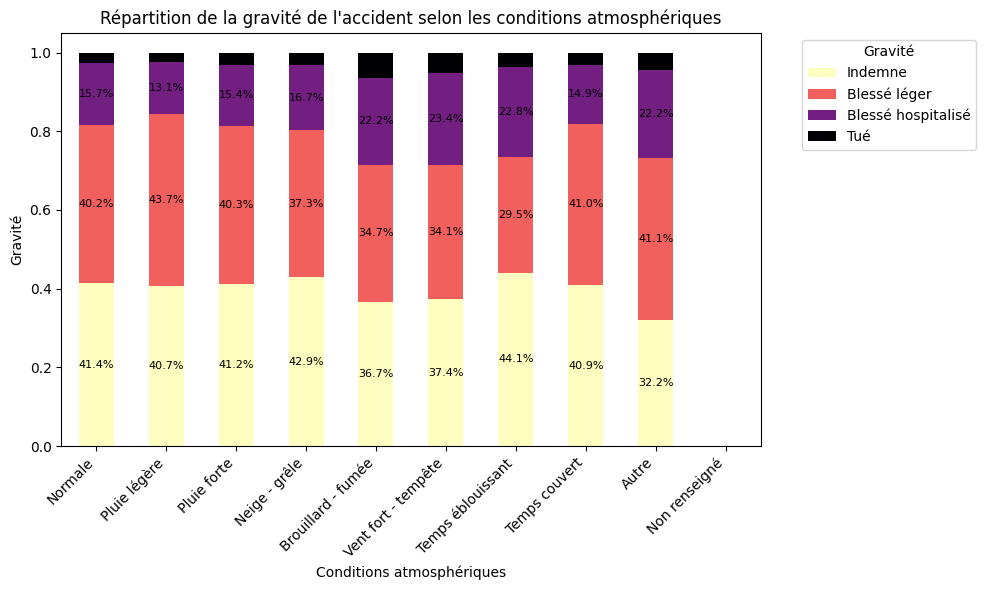

In [ ]:


tc_atm_grav = tab_cont_grav(df_final, "atm", ordre_lignes, ordre_colonnes)

bar_chart(tc_atm_grav, "Conditions atmosphériques", "Répartition de la gravité de l'accident selon les conditions atmosphériques")

#### Conditions de la surface au sol

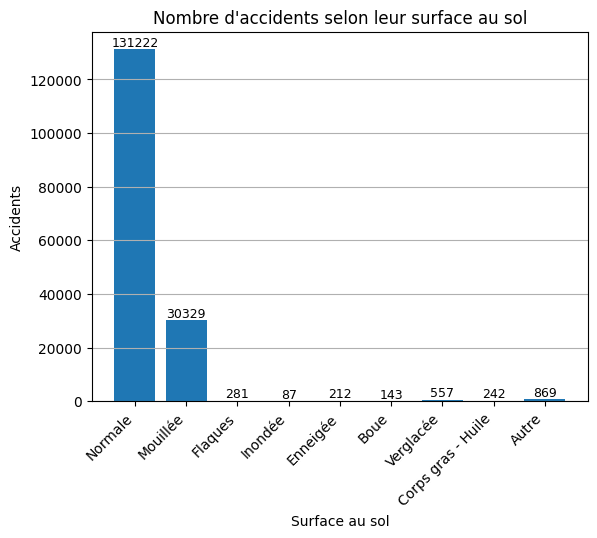

In [ ]:
ordre_lignes_surf = [
   "Normale",
   "Mouillée",
   "Flaques",
   "Inondée",
   "Enneigée",
   "Boue",
   "Verglacée",
   "Corps gras - Huile",
   "Autre"
]

nb_accidents_par(df_final, "surf", "Surface au sol", ordre_lignes_surf, True)

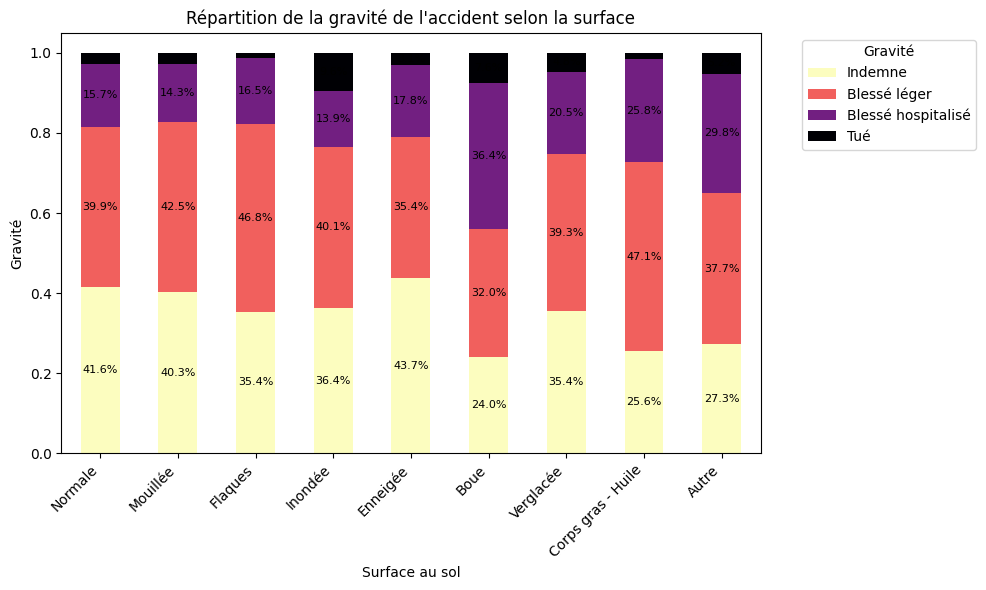

In [ ]:

tc_surf_grav = tab_cont_grav(df_final, "surf", ordre_lignes_surf, ordre_colonnes)
bar_chart(tc_surf_grav, "Surface au sol", "Répartition de la gravité de l'accident selon la surface")

La proportion de tués est plus grande lorsque les accidents ont lieu sur des surfaces inondées (9,2 %) ou boueuses (8,0 %) par rapport aux autres situations. La part de blessés hospitalisées est particulièrement importante dans ce second cas (35,7 %), alors qu'il n'excède pas 25 % quand la surface est spécifiée.

### Conditions de l'accident

#### Type de collision

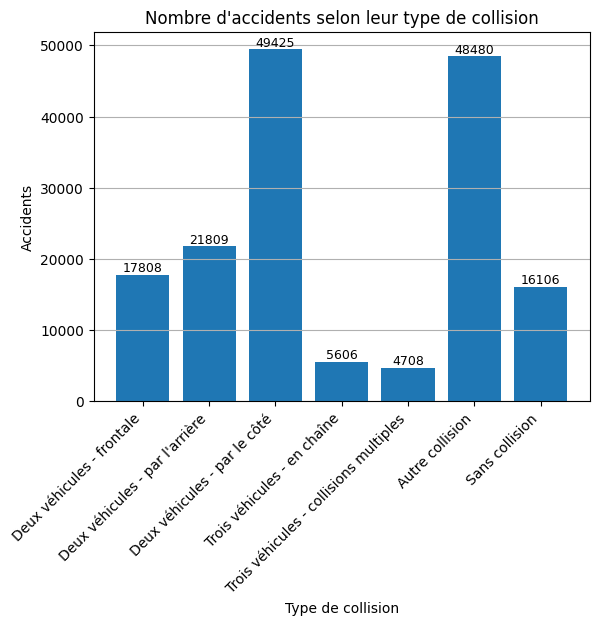

In [ ]:
ordre_lignes_col = [
    "Deux véhicules - frontale",
    "Deux véhicules - par l'arrière",
    "Deux véhicules - par le côté",
    "Trois véhicules - en chaîne",
    "Trois véhicules - collisions multiples",
    "Autre collision",
    "Sans collision"
]

nb_accidents_par(df_final, "col", "Type de collision", ordre_lignes_col, True)

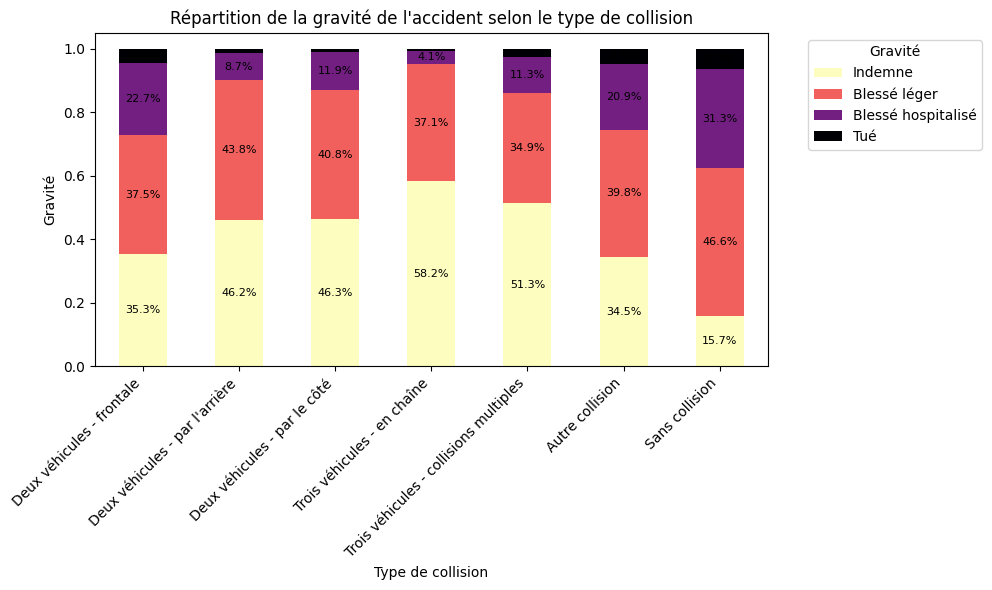

In [ ]:


tc_col_grav = tab_cont_grav(df_final, "col", ordre_lignes_col, ordre_colonnes)
bar_chart(tc_col_grav, "Type de collision", "Répartition de la gravité de l'accident selon le type de collision")

L'absence de collision est le cas le plus fatal (6,4 %) parmi les situations où le type de collision est spécifié, et c'est aussi le cas avec le moins d'indemnes : 16,8 % seulement. Elle est suivie par la catégorie « Autre », puis par la collision frontale entre deux véhicules, et le cas de collisions multiples entre trois véhicules. On remarque que pour les collisions entre trois véhicules, plus de la moitié des usagers impliqués dans l'accident s'en sortent indemnes.

#### Obstacle fixe percuté

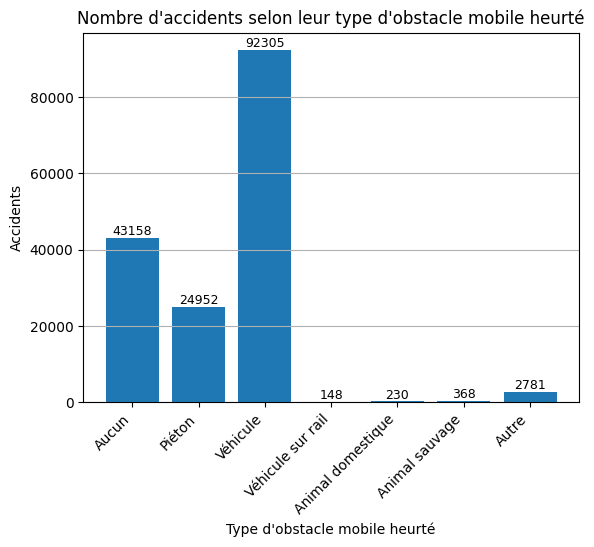

In [ ]:
ordre_lignes_obsm = [
    "Aucun",
    "Piéton",
    "Véhicule",
    "Véhicule sur rail",
    "Animal domestique",
    "Animal sauvage",
    "Autre"
]

nb_accidents_par(df_final, "obsm", "Type d'obstacle mobile heurté", ordre_lignes_obsm, True)

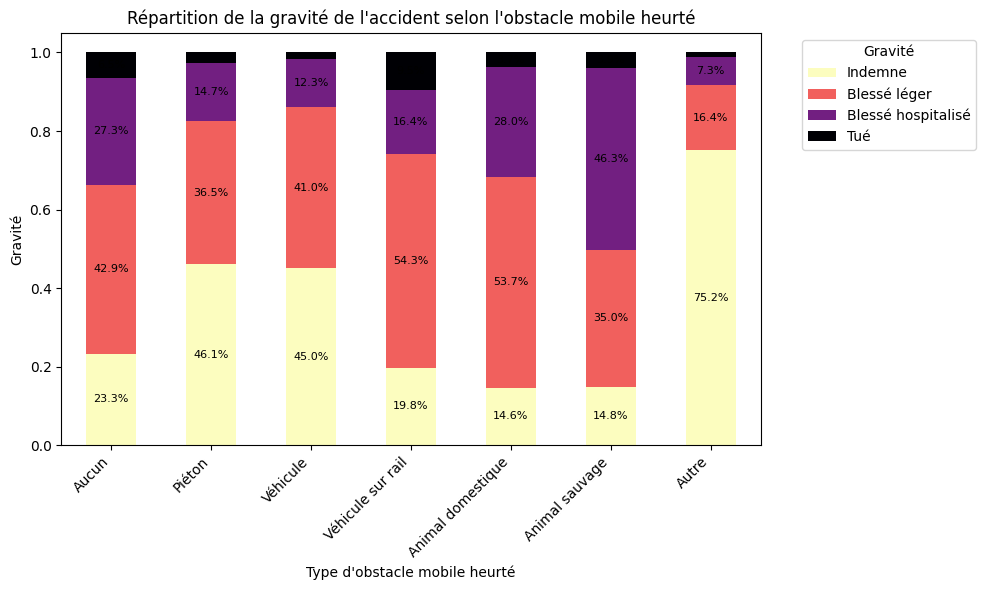

In [ ]:


tc_obsm_grav = tab_cont_grav(df_final, "obsm", ordre_lignes_obsm, ordre_colonnes)
bar_chart(tc_obsm_grav, "Type d'obstacle mobile heurté", "Répartition de la gravité de l'accident selon l'obstacle mobile heurté")

#### Obstacle fixe

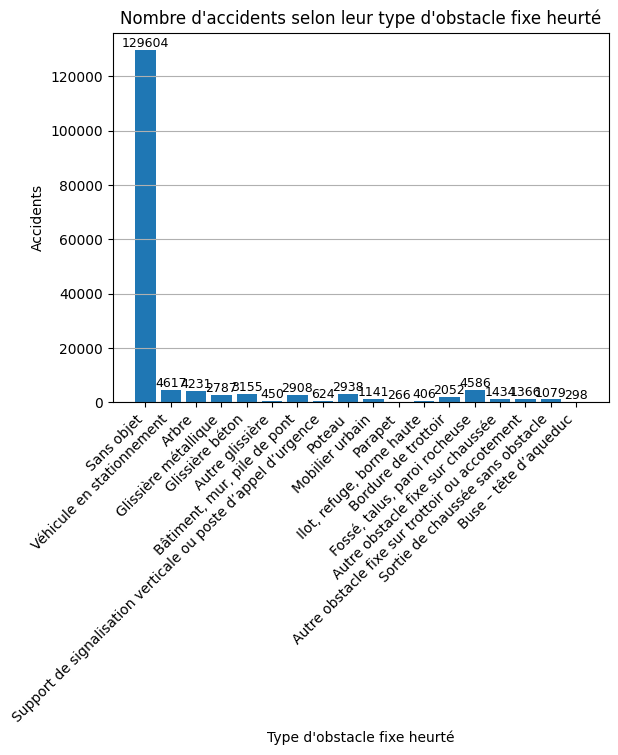

In [ ]:
ordre_lignes_obs = [
    "Sans objet",
    "Véhicule en stationnement",
    "Arbre",
    "Glissière métallique",
    "Glissière béton",
    "Autre glissière",
    "Bâtiment, mur, pile de pont",
    "Support de signalisation verticale ou poste d’appel d’urgence",
    "Poteau",
    "Mobilier urbain",
    "Parapet",
    "Ilot, refuge, borne haute",
    "Bordure de trottoir",
    "Fossé, talus, paroi rocheuse",
    "Autre obstacle fixe sur chaussée",
    "Autre obstacle fixe sur trottoir ou accotement",
    "Sortie de chaussée sans obstacle",
    "Buse – tête d’aqueduc"
]


nb_accidents_par(df_final, "obs", "Type d'obstacle fixe heurté", ordre_lignes_obs, True)

# nb_accidents_obs = (
#     df_final.groupby("obs")
#     .count()
#     .reset_index()
#     .iloc[:, :2]
#     .rename(columns={"obs": "Obstacle fixe heurté"})
#     .rename(columns={"Num_Acc": "Nombre d'accidents"})
#     .set_index("Obstacle fixe heurté")
#     .reindex(ordre_lignes)
#     .reset_index()
# )
# nb_accidents_obs



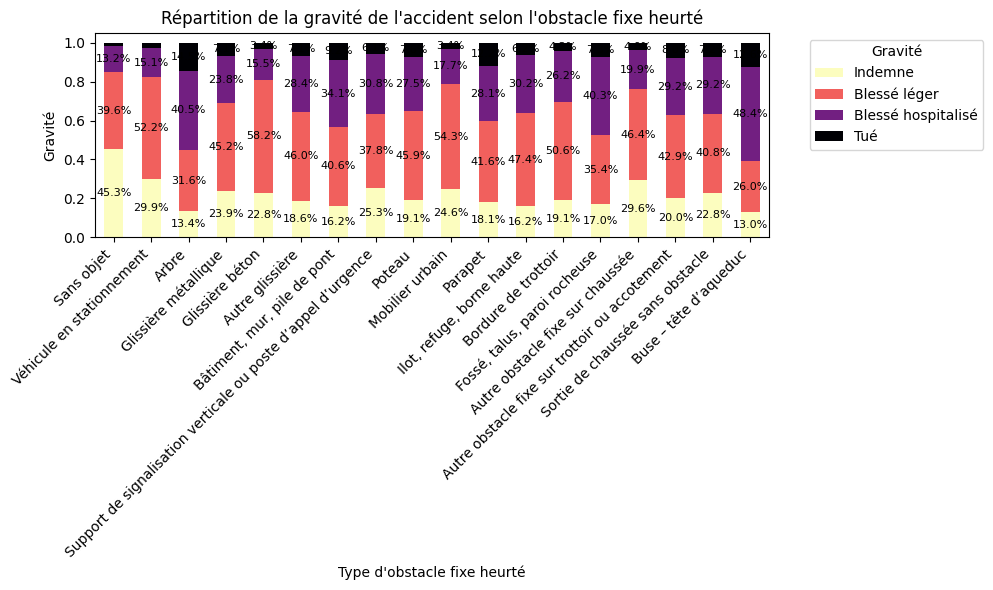

In [ ]:

tc_obs_grav = tab_cont_grav(df_final, "obs", ordre_lignes_obs, ordre_colonnes)
bar_chart(tc_obs_grav, "Type d'obstacle fixe heurté", "Répartition de la gravité de l'accident selon l'obstacle fixe heurté")

In [ ]:
# sns.boxplot(data=df_final, x="grav", y="nbv")

# plt.title("Distribution du nombre de voies selon la gravité")
# plt.xlabel("Gravité")
# plt.ylabel("Nombre de voies")
# plt.xticks(rotation=20, ha="right")
# plt.tight_layout()
# plt.show()

In [380]:
df_final["trajet"].unique()

array(['Domicile - École', 'Utilisation professionnelle',
       'Promenade - loisirs', nan, 'Domicile - Travail', 'Autre',
       'Courses - achats'], dtype=object)

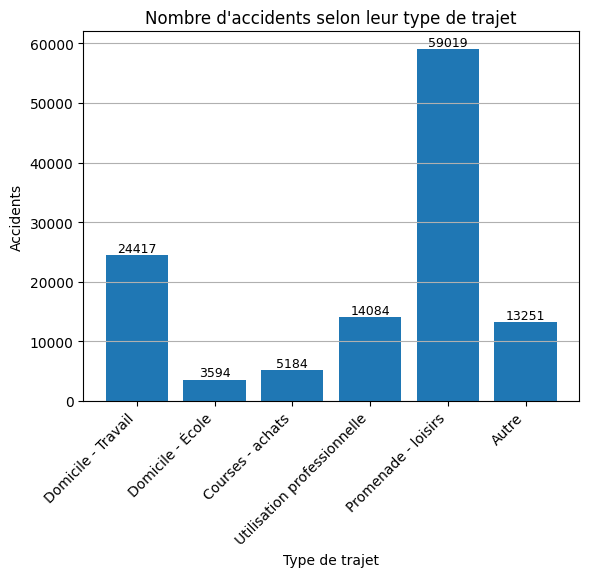

In [381]:
ordre_lignes_trajet = [
    "Domicile - Travail",
    "Domicile - École",
    "Courses - achats",
    "Utilisation professionnelle",
    "Promenade - loisirs",
    "Autre"
]

nb_accidents_par(df_final, "trajet", "Type de trajet", ordre_lignes_trajet, True)

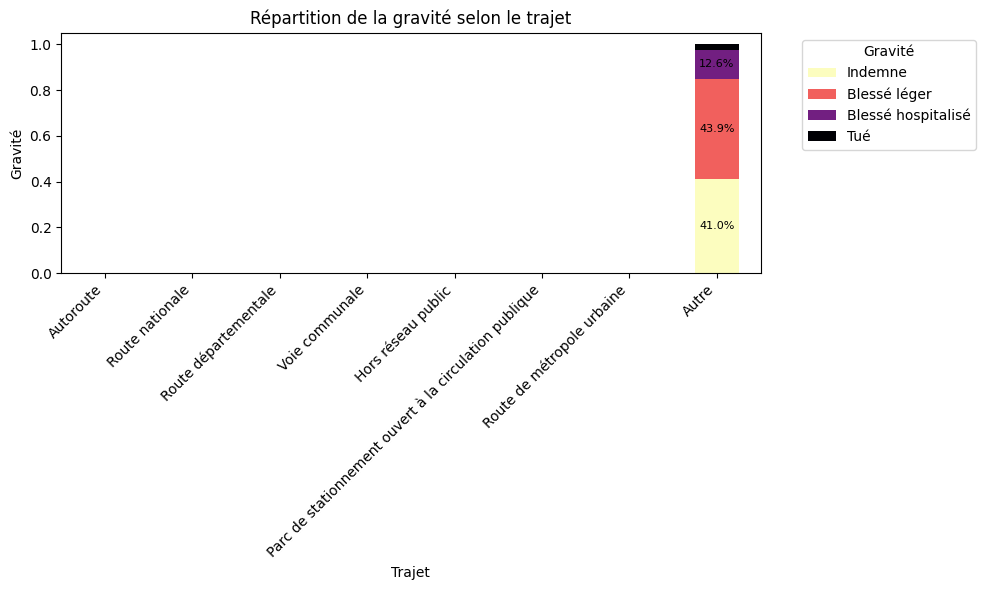

In [382]:


tc_trajet_grav = tab_cont_grav(df_final, "trajet", ordre_lignes, ordre_colonnes)
bar_chart(tc_trajet_grav, "Trajet", "Répartition de la gravité selon le trajet")

KeyError: 'senc'

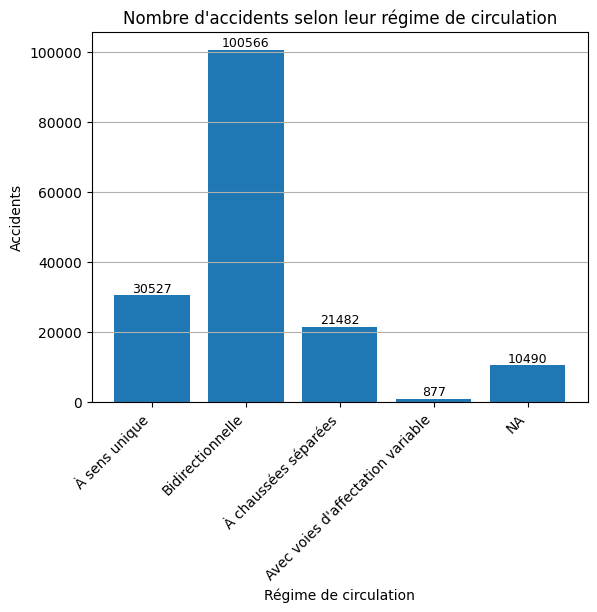

In [357]:
ordre_lignes_circ = [
    "À sens unique",
    "Bidirectionnelle",
    "À chaussées séparées",
    "Avec voies d'affectation variable",
    "NA"
]

nb_accidents_par(df_final.fillna({"circ": "NA"}), "circ", "Régime de circulation", ordre_lignes_circ, True)


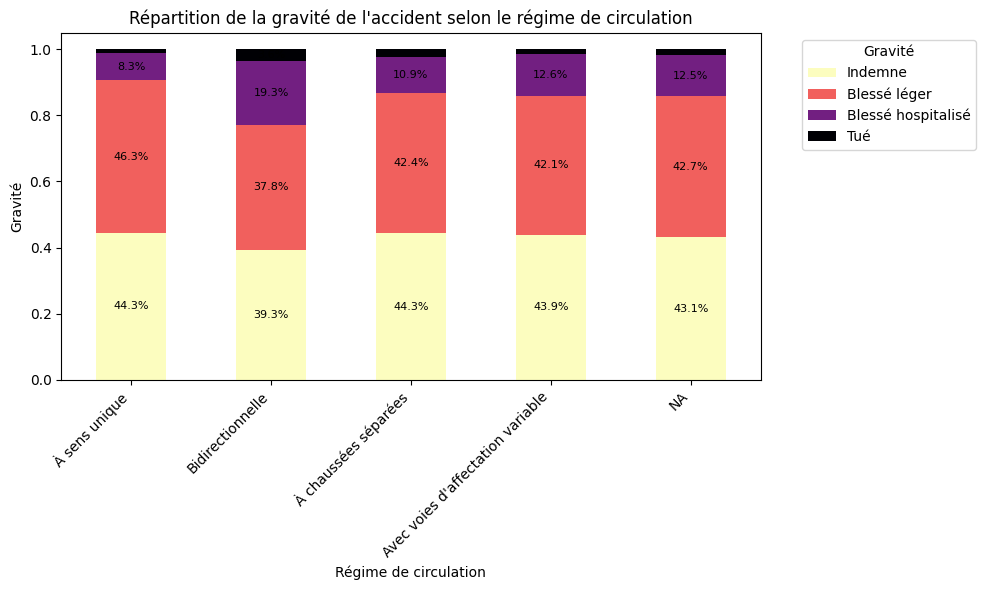

In [361]:

tc_circ_grav = tab_cont_grav(df_final.fillna({"circ": "NA"}), "circ", ordre_lignes_circ, ordre_colonnes)
bar_chart(tc_circ_grav, "Régime de circulation", "Répartition de la gravité de l'accident selon le régime de circulation")

In [368]:
df_final["choc"]

0                Avant
1          Avant droit
2         Avant gauche
3         Avant gauche
4                Avant
              ...     
377697     Côté gauche
377698     Côté gauche
377699           Avant
377700           Avant
377701         Arrière
Name: choc, Length: 367699, dtype: object

In [ ]:
ordre_lignes_choc = [
"Aucun",
"Avant",
"Avant droit",
"Avant gauche",
"Arrière",
"Arrière droit",
"Arrière gauche",
"Côté droit",
"Côté gauche",
"Chocs multiples (tonneaux)"
]

nb_accidents_par(df_final, "choc", "choc initial", ordre_lignes_choc, True)

In [ ]:
tc_choc_grav = tab_cont_grav(df_final, "choc", ordre_lignes_choc, ordre_colonnes)
bar_chart(tc_choc_grav, "Choc initial", "Répartition de la gravité de l'accident selon l'endroit du choc initial")

In [372]:
df_final["infra"].unique()

array(['Aucun', 'Carrefour aménagé', 'Autre', 'Zone piétonne', nan,
       'Chantier', "Bretelle d'échangeur ou de raccordement",
       'Souterrain - Tunnel', 'Pont - Autopont', 'Voie ferrée',
       'Zone de péage'], dtype=object)

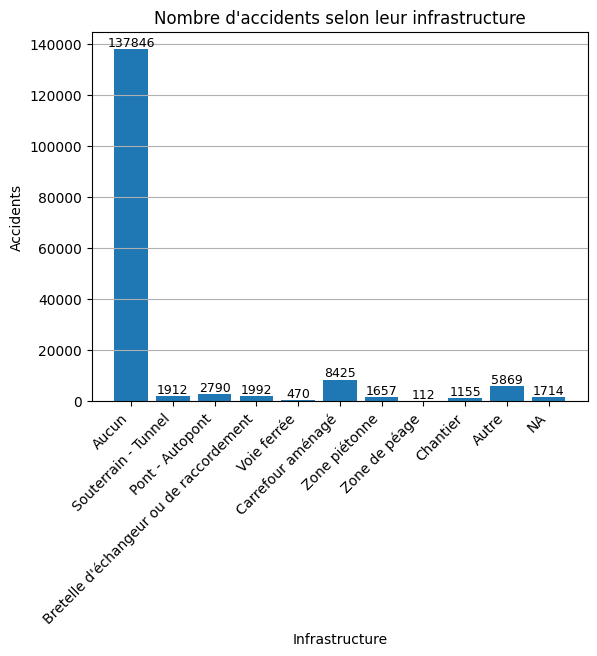

In [376]:
ordre_lignes_infra = [
    "Aucun",
    "Souterrain - Tunnel",
    "Pont - Autopont",
    "Bretelle d'échangeur ou de raccordement",
    "Voie ferrée",
    "Carrefour aménagé",
    "Zone piétonne",
    "Zone de péage",
    "Chantier",
    "Autre",
    "NA"
]

nb_accidents_par(df_final.fillna({"infra": "NA"}), "infra", "Infrastructure", ordre_lignes_infra, True)

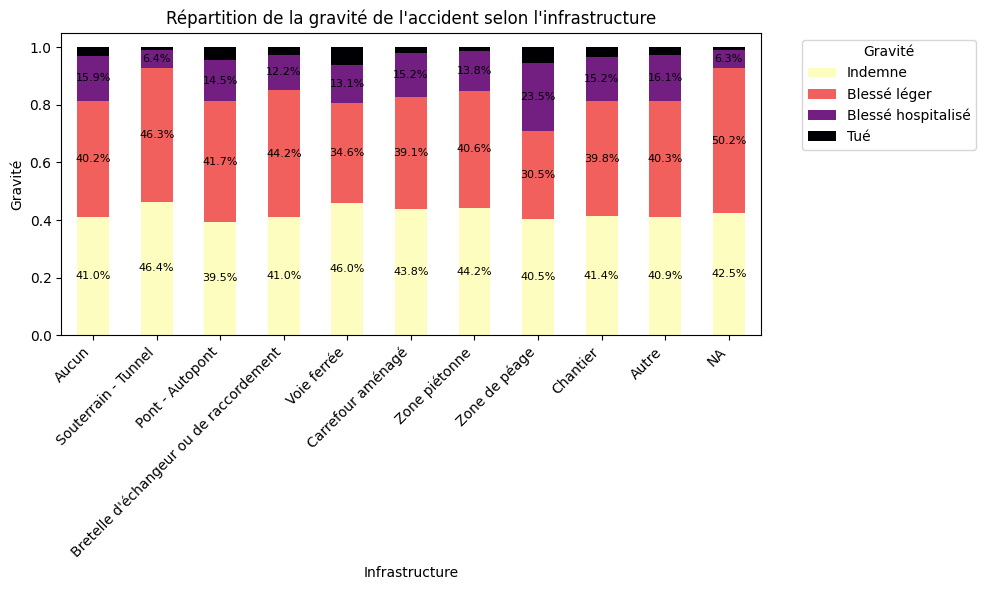

In [377]:

tc_infra_grav = tab_cont_grav(df_final.fillna({"infra": "NA"}), "infra", ordre_lignes_infra, ordre_colonnes)
bar_chart(tc_infra_grav, "Infrastructure", "Répartition de la gravité de l'accident selon l'infrastructure")

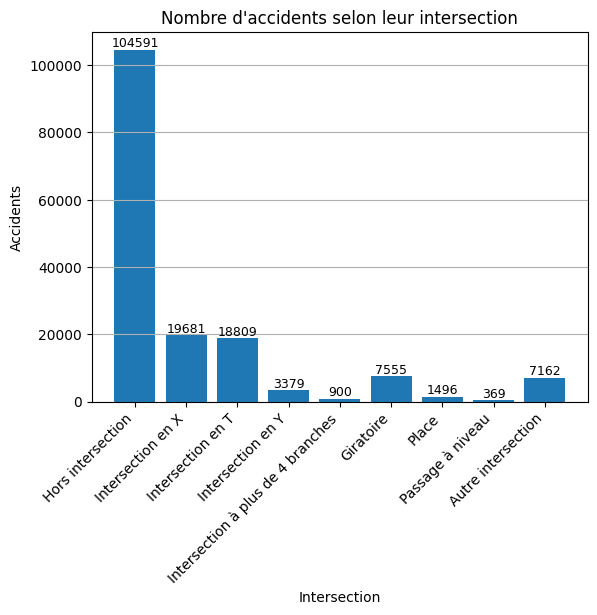

In [378]:
ordre_lignes_int = [
    "Hors intersection",
    "Intersection en X",
    "Intersection en T",
    "Intersection en Y",
    "Intersection à plus de 4 branches",
    "Giratoire",
    "Place",
    "Passage à niveau",
    "Autre intersection"
]

nb_accidents_par(df_final, "int", "Intersection", ordre_lignes_int, True)

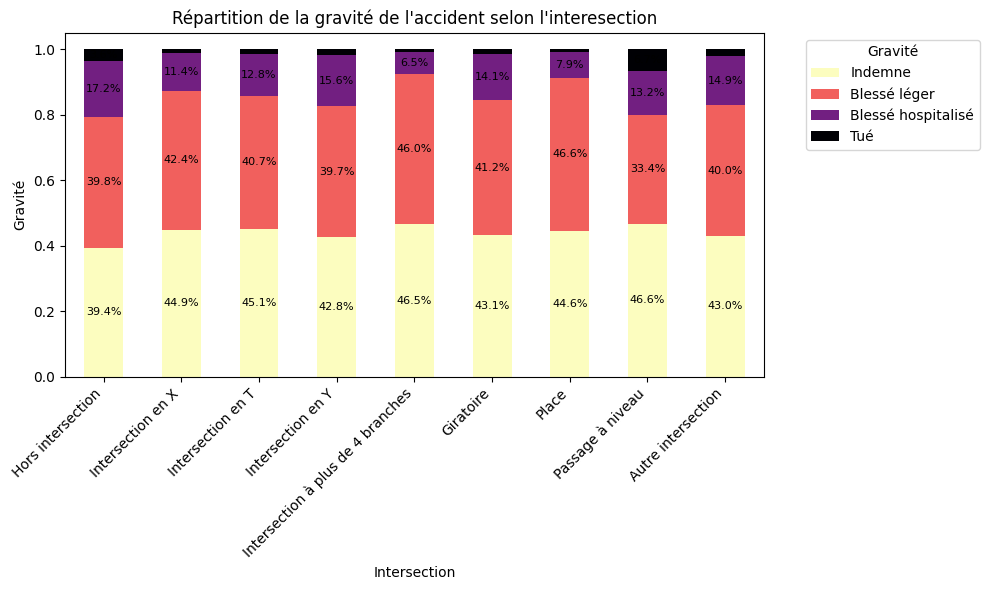

In [379]:
tc_int_grav = tab_cont_grav(df_final, "int", ordre_lignes_int, ordre_colonnes)
bar_chart(tc_int_grav, "Intersection", "Répartition de la gravité de l'accident selon l'interesection")

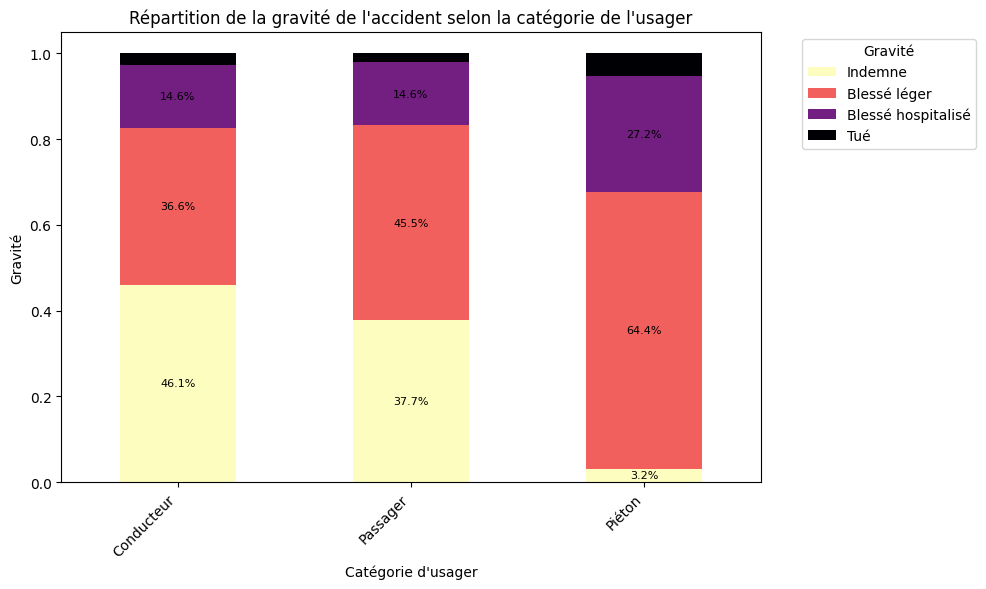

In [385]:
ordre_lignes_catu = [
    "Conducteur",
    "Passager",
    "Piéton"
]

tc_catu_grav = tab_cont_grav(df_final, "catu", ordre_lignes_catu, ordre_colonnes)
bar_chart(tc_catu_grav, "Catégorie d'usager", "Répartition de la gravité de l'accident selon la catégorie de l'usager")


In [386]:
df_final["secu1"].unique()

array(['Ceinture', 'Aucun équipement', 'Non déterminable', 'Casque',
       'Autre', 'Dispositif enfants', 'Airbag (2RM/3RM)',
       'Gants (2RM/3RM)', 'Gilet réfléchissant',
       'Gants + Airbag (2RM/3RM)'], dtype=object)

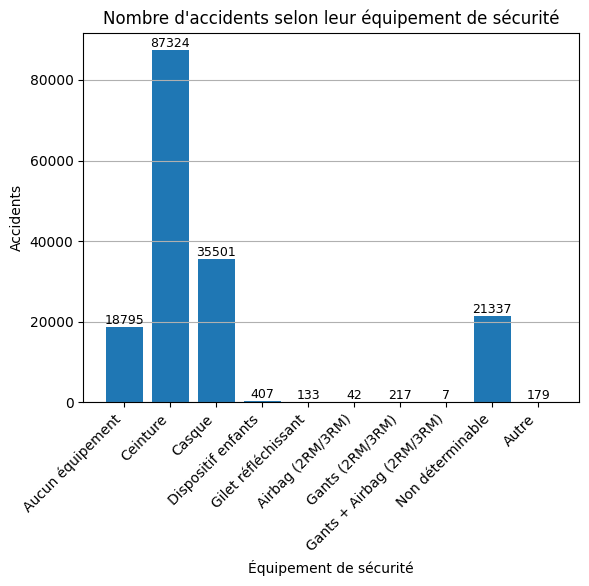

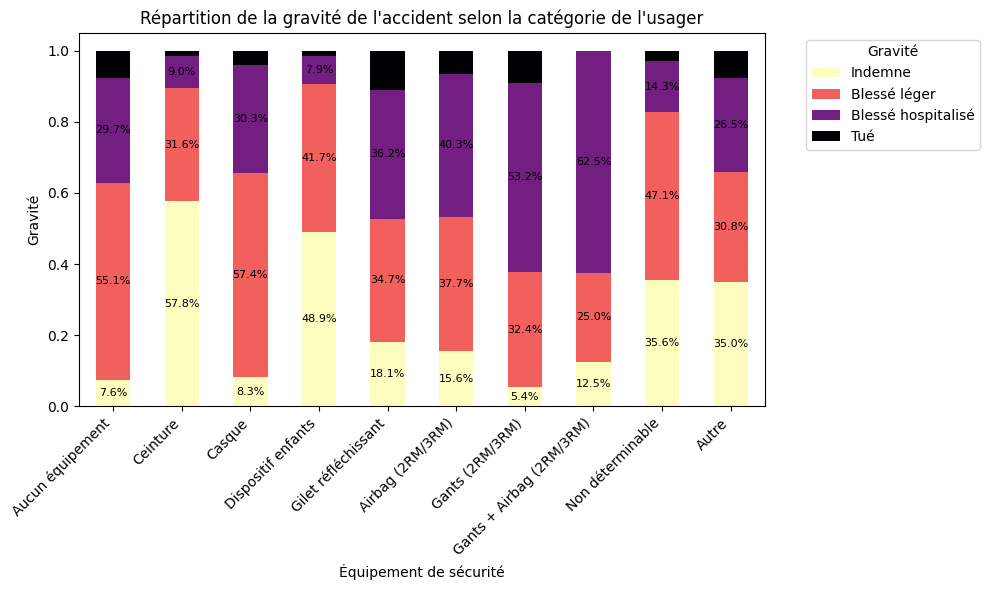

In [ ]:
ordre_lignes_secu1 = [
    "Aucun équipement",
    "Ceinture",
    "Casque",
    "Dispositif enfants",
    "Gilet réfléchissant",
    "Airbag (2RM/3RM)",
    "Gants (2RM/3RM)",
    "Gants + Airbag (2RM/3RM)",
    "Non déterminable",
    "Autre"
]


nb_accidents_par(df_final, "secu1", "Équipement de sécurité", ordre_lignes_secu1, True)

tc_secu1_grav = tab_cont_grav(df_final, "secu1", ordre_lignes_secu1, ordre_colonnes)
bar_chart(tc_secu1_grav, "Équipement de sécurité", "Répartition de la gravité de l'accident selon la catégorie de l'usager")


In [395]:
df_final["catv"].unique()

array(['VL', 'PL', 'VU', 'Voiturette', 'Scooter', 'Motocyclette',
       'Cyclomoteur', 'Bicyclette', 'VAE', 'EDP à moteur',
       'Tracteur routier', 'Autre véhicule', '3RM', 'Autocar', 'Autobus',
       'EDP sans moteur', 'Indéterminable', 'Tracteur agricole', 'Quad',
       'Train', 'Tramway', 'Engin spécial'], dtype=object)

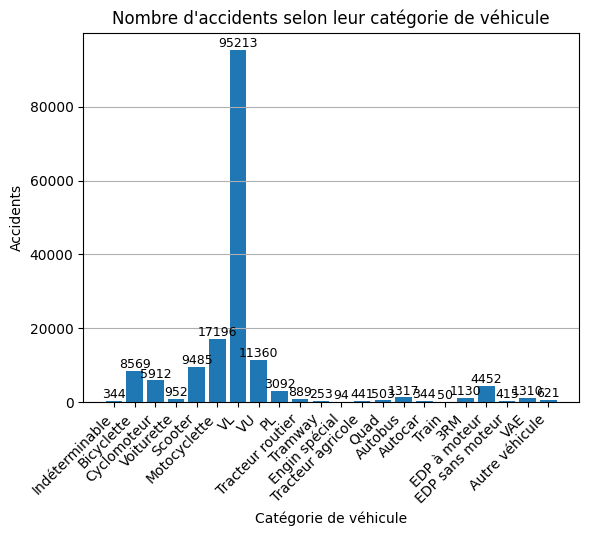

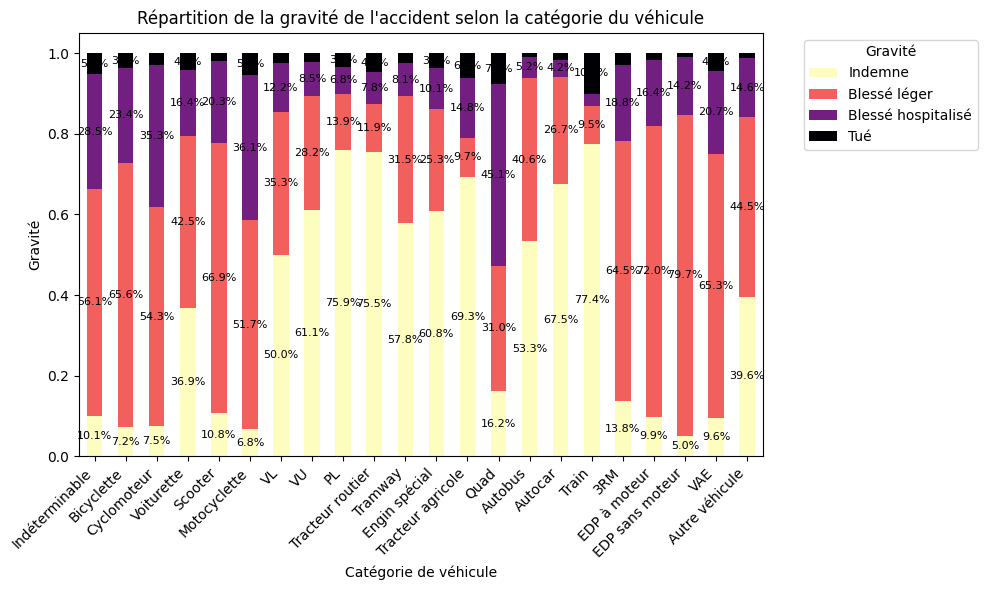

In [397]:


ordre_lignes_catv = [
    "Indéterminable",
    "Bicyclette",
    "Cyclomoteur",
    "Voiturette",
    "Scooter",
    "Motocyclette",
    # "Side-car",
    "VL",
    "VU",
    "PL",
    "Tracteur routier",
    # "Transport en commun",
    "Tramway",
    "Engin spécial",
    "Tracteur agricole",
    "Quad",
    "Autobus",
    "Autocar",
    "Train",
    "3RM",
    "EDP à moteur",
    "EDP sans moteur",
    "VAE",
    "Autre véhicule"
]

nb_accidents_par(df_final, "catv", "Catégorie de véhicule", ordre_lignes_catv, True)


tc_catv_grav = tab_cont_grav(df_final, "catv", ordre_lignes_catv, ordre_colonnes)
bar_chart(tc_catv_grav, "Catégorie de véhicule", "Répartition de la gravité de l'accident selon la catégorie du véhicule")



In [365]:
ordre_lignes_motor = [
    "Inconnue",
    "Hydrocarbures",
    "Hybride électrique",
    "Electrique",
    "Hydrogène",
    "Humaine",
    "Autre"
]

nb_accidents_par(df_final, "motor", "Moteur", ordre_lignes_motor, True)


KeyError: 'motor'